# Credit Risk ML Pipeline: Production Banking Standard
This notebook demonstrates the end-to-end ML pipeline for credit risk assessment.
It adheres to strict banking rules, removing synthetic oversampling (SMOTE) and preventing target leakage.

**Key Features:**
1. Original authentic dataset only (`Loan_Default.csv`).
2. Robust financial constraint handling (LTV, DTI/FOIR clipping).
3. Engineered financial ratios.
4. `ColumnTransformer` for perfectly reproducible preprocessing.
5. Calibrated ensemble probabilities.
6. Hard banking deterministic rule overrides.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve


## 1. Data Ingestion
Load ONLY the original dataset.

In [2]:
df = pd.read_csv('../data/raw/Loan_Default.csv')
print(f"Original shape: {df.shape}")
df.head()


Original shape: (148670, 34)


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


## 2. Remove Dangerous & Leakage Columns
Dropping target leakage columns, fairness risk variables (Gender, age), and zero-variance/useless columns.

In [3]:
drop_cols = [
    "Gender",
    "age",
    "rate_of_interest",
    "Interest_rate_spread",
    "Upfront_charges",
    "construction_type",
    "Secured_by",
    "Security_Type",
    "open_credit"
]
# ID and year columns
drop_cols.extend(["ID", "year"])

df_clean = df.drop(columns=[col for col in drop_cols if col in df.columns])
print(f"Shape after dropping columns: {df_clean.shape}")


Shape after dropping columns: (148670, 23)


## 3. Clean Financial Outliers
Implement realistic banking constraints.

In [4]:
# 1. Clip impossible ratios
if "LTV" in df_clean.columns:
    df_clean["LTV"] = df_clean["LTV"].clip(upper=150)
if "dtir1" in df_clean.columns:
    df_clean["dtir1"] = df_clean["dtir1"].clip(upper=65)

# 2. Handle income <= 0
if "income" in df_clean.columns:
    df_clean.loc[df_clean["income"] <= 0, "income"] = np.nan

# 3. Handle zero or negative property values
if "property_value" in df_clean.columns:
    df_clean.loc[df_clean["property_value"] <= 0, "property_value"] = np.nan


## 4. Feature Engineering
Create safe financial ratios to improve underwriting realism.

In [5]:
# Loan to Income
if "loan_amount" in df_clean.columns and "income" in df_clean.columns:
    df_clean["loan_to_income"] = df_clean["loan_amount"] / (df_clean["income"] + 1)

# Derived FOIR (Fixed Obligation to Income Ratio)
if "dtir1" in df_clean.columns:
    df_clean["derived_foir"] = df_clean["dtir1"] / 100.0
else:
    df_clean["derived_foir"] = 0.0

# Estimated EMI (Assuming 30yr 7% mortgage as baseline proxy)
if "loan_amount" in df_clean.columns and "term" in df_clean.columns:
    monthly_rate = 0.07 / 12
    # Simple proxy if term is missing
    tenure_months = df_clean["term"].fillna(360)
    df_clean["estimated_emi"] = df_clean["loan_amount"] * (monthly_rate * (1 + monthly_rate)**tenure_months) / ((1 + monthly_rate)**tenure_months - 1)

# Loan to Property Ratio (LTV proxy)
if "loan_amount" in df_clean.columns and "property_value" in df_clean.columns:
    df_clean["loan_to_property_ratio"] = df_clean["loan_amount"] / df_clean["property_value"]


## Export Cleaned Training Data
Saving the exact cleaned dataframe before passing to the sklearn pipeline.

In [6]:
os.makedirs('../data/processed', exist_ok=True)
clean_csv_path = '../data/processed/clean_training_data.csv'
df_clean.to_csv(clean_csv_path, index=False)
print(f"Saved clean training dataset to {clean_csv_path}")


Saved clean training dataset to ../data/processed/clean_training_data.csv


## 5. Build Proper sklearn Pipeline
No manual encoding. The `ColumnTransformer` will handle everything automatically.

In [7]:
target = "Status"
X = df_clean.drop(columns=[target])
y = df_clean[target]

# Identify columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

# Define Preprocessors
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numerical_cols),
    ('cat', cat_transformer, categorical_cols)
])

# Save feature metadata for backend inference mapping
feature_metadata = {
    "numerical_columns": numerical_cols,
    "categorical_columns": categorical_cols,
    "expected_features": X.columns.tolist()
}
with open("../models/feature_metadata.json", "w") as f:
    json.dump(feature_metadata, f, indent=2)

print("Preprocessing pipeline initialized and metadata saved.")


Preprocessing pipeline initialized and metadata saved.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Training shapes: X={X_train.shape}, y={y_train.shape}")


Training shapes: X=(118936, 26), y=(118936,)


## 6. Train Models & Add Probability Calibration
Training `LogisticRegression`, `RandomForest`, and `GradientBoosting` inside full `Pipeline` objects. Using `class_weight='balanced'` instead of SMOTE.

In [9]:
# 1. Logistic Regression
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
print("Training Logistic Regression...")
lr_model.fit(X_train, y_train)

# 2. Random Forest (Calibrated)
rf_base = RandomForestClassifier(class_weight='balanced', n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_calibrated = CalibratedClassifierCV(estimator=rf_base, method='sigmoid', cv=3)
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf_calibrated)
])
print("Training Random Forest...")
rf_model.fit(X_train, y_train)

# 3. Gradient Boosting (Calibrated)
gb_base = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
gb_calibrated = CalibratedClassifierCV(estimator=gb_base, method='sigmoid', cv=3)
gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', gb_calibrated)
])
print("Training Gradient Boosting...")
gb_model.fit(X_train, y_train)

print("All models trained successfully!")


Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...
All models trained successfully!


## 7. Model Diagnostics
Evaluate the models and generate ROC-AUC, Precision/Recall, and Calibration curves.

In [10]:
def evaluate_model(model, name, X_t, y_t):
    y_pred = model.predict(X_t)
    y_prob = model.predict_proba(X_t)[:, 1]
    
    print(f"\n--- {name} ---")
    print("ROC-AUC:", roc_auc_score(y_t, y_prob))
    print(classification_report(y_t, y_pred))
    
    return y_prob

lr_probs = evaluate_model(lr_model, "Logistic Regression", X_test, y_test)
rf_probs = evaluate_model(rf_model, "Random Forest", X_test, y_test)
gb_probs = evaluate_model(gb_model, "Gradient Boosting", X_test, y_test)



--- Logistic Regression ---
ROC-AUC: 0.8482552666901061
              precision    recall  f1-score   support

           0       0.89      0.89      0.89     22406
           1       0.65      0.66      0.66      7328

    accuracy                           0.83     29734
   macro avg       0.77      0.77      0.77     29734
weighted avg       0.83      0.83      0.83     29734


--- Random Forest ---
ROC-AUC: 0.8866027312748028
              precision    recall  f1-score   support

           0       0.89      0.97      0.93     22406
           1       0.89      0.63      0.74      7328

    accuracy                           0.89     29734
   macro avg       0.89      0.80      0.83     29734
weighted avg       0.89      0.89      0.88     29734


--- Gradient Boosting ---
ROC-AUC: 0.8989679487510559
              precision    recall  f1-score   support

           0       0.90      0.98      0.94     22406
           1       0.93      0.65      0.77      7328

    accuracy       

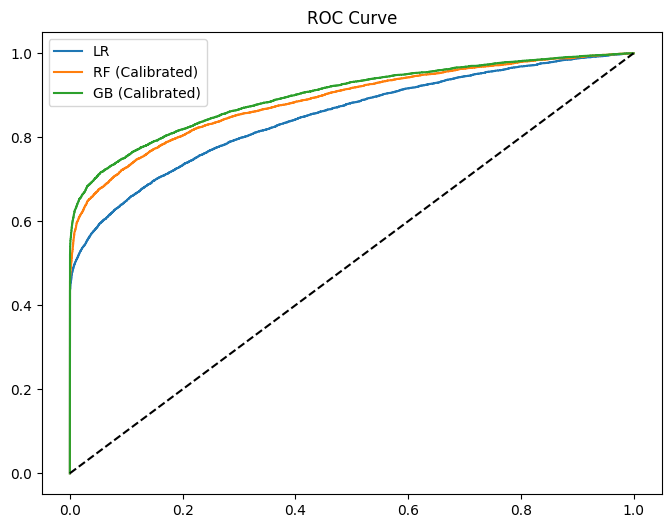

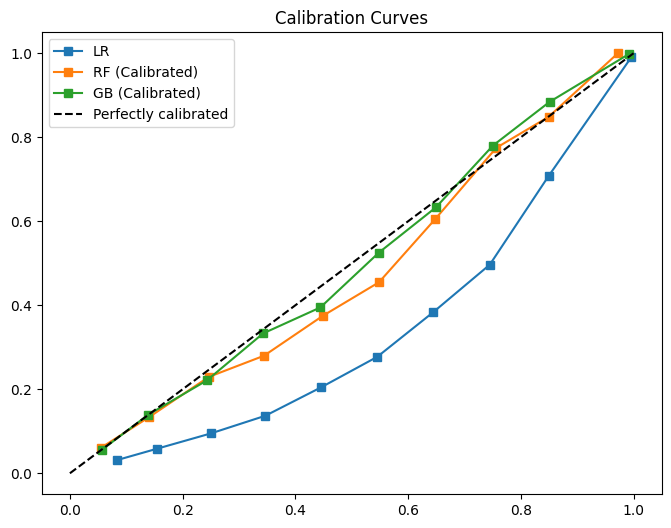

In [11]:
# ROC Curve
plt.figure(figsize=(8,6))
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_probs)

plt.plot(fpr_lr, tpr_lr, label="LR")
plt.plot(fpr_rf, tpr_rf, label="RF (Calibrated)")
plt.plot(fpr_gb, tpr_gb, label="GB (Calibrated)")
plt.plot([0,1],[0,1], 'k--')
plt.title("ROC Curve")
plt.legend()
plt.show()

# Calibration Curve
plt.figure(figsize=(8,6))
fraction_of_positives_lr, mean_predicted_value_lr = calibration_curve(y_test, lr_probs, n_bins=10)
fraction_of_positives_rf, mean_predicted_value_rf = calibration_curve(y_test, rf_probs, n_bins=10)
fraction_of_positives_gb, mean_predicted_value_gb = calibration_curve(y_test, gb_probs, n_bins=10)

plt.plot(mean_predicted_value_lr, fraction_of_positives_lr, "s-", label="LR")
plt.plot(mean_predicted_value_rf, fraction_of_positives_rf, "s-", label="RF (Calibrated)")
plt.plot(mean_predicted_value_gb, fraction_of_positives_gb, "s-", label="GB (Calibrated)")
plt.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
plt.title("Calibration Curves")
plt.legend()
plt.show()


## 8. Ensemble Logic & Hard Banking Rules
Demonstrate the weighted ensemble logic and extreme borrower overrides within the notebook.

In [12]:
def evaluate_borrower(borrower_dict):
    # 1. Hard Rules First
    dti = borrower_dict.get("dti", 0)
    ltv = borrower_dict.get("ltv", 0)
    foir = borrower_dict.get("foir", 0)
    credit_score = borrower_dict.get("credit_score", 0)
    income = borrower_dict.get("income", 0)
    
    reasons = []
    if credit_score < 550: reasons.append("Reject: Credit Score < 550")
    if ltv > 120: reasons.append("Reject: LTV > 120")
    if foir > 55 or dti > 55: reasons.append("Reject: DTI/FOIR > 55")
    if income <= 0: reasons.append("Manual Review: Zero/Negative Income")
        
    if reasons:
        return {"final_risk_level": "High Risk", "override_triggered": True, "reasons": reasons, "ml_score": 1.0}
    
    # 2. Build DataFrame for inference
    df_inf = pd.DataFrame([borrower_dict])
    
    # Align with expected columns
    for col in feature_metadata["expected_features"]:
        if col not in df_inf.columns:
            df_inf[col] = np.nan
            
    df_inf = df_inf[feature_metadata["expected_features"]]
    
    # 3. Predict Proba
    lr_p = lr_model.predict_proba(df_inf)[0][1]
    rf_p = rf_model.predict_proba(df_inf)[0][1]
    gb_p = gb_model.predict_proba(df_inf)[0][1]
    
    # Weighted Ensemble
    final_score = 0.25 * lr_p + 0.40 * rf_p + 0.35 * gb_p
    
    risk_level = "Low Risk"
    if final_score > 0.4: risk_level = "Medium Risk"
    if final_score > 0.7: risk_level = "High Risk"
        
    return {
        "final_risk_level": risk_level,
        "override_triggered": False,
        "reasons": [],
        "ml_score": final_score,
        "individual_scores": {"lr": lr_p, "rf": rf_p, "gb": gb_p}
    }


In [13]:
extreme_borrower = {
    "credit_score": 300,
    "dti": 490,
    "foir": 189,
    "loan_amount": 500000000,
    "income": 1000
}

res = evaluate_borrower(extreme_borrower)
print("Extreme Borrower Result:")
print(json.dumps(res, indent=2))


Extreme Borrower Result:
{
  "final_risk_level": "High Risk",
  "override_triggered": true,
  "reasons": [
    "Reject: Credit Score < 550",
    "Reject: DTI/FOIR > 55"
  ],
  "ml_score": 1.0
}


## 9. Save Full Pipelines
Save the complete `Pipeline` objects. No raw models without preprocessing.

In [14]:
os.makedirs("../models", exist_ok=True)

joblib.dump(lr_model, "../models/logistic_pipeline.pkl")
joblib.dump(rf_model, "../models/rf_pipeline.pkl")
joblib.dump(gb_model, "../models/gb_pipeline.pkl")

print("All FULL pipelines exported successfully to backend/models/")


All FULL pipelines exported successfully to backend/models/
